<a href="https://colab.research.google.com/github/shavel28/StockSight-AI-PJK-GM073/blob/main/Notebooks/Data_Engineering_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# StockSight AI - Data Engineering Pipeline

### Project ID: PJK-GM073

### Role: Data Engineer

### Author: Shava Selvia Ramadhani Subekti

## Deskripsi

Notebook ini berisi proses Data Engineering untuk proyek StockSight AI, mulai dari data ingestion, data cleaning, validasi data, integrasi Hari Libur Nasional Indonesia, feature engineering, transformasi time series, analisis outlier, perhitungan Safety Stock dan Reorder Point (ROP), hingga penyediaan dataset siap pakai untuk proses forecasting oleh Machine Learning Engineer.

## Pembaruan Berdasarkan Hasil Mentoring

* Konversi kolom tanggal ke format datetime.
* Perbaikan penanganan missing value dengan imputasi yang sesuai.
* Penambahan fitur promo berdasarkan kolom Discount.
* Penambahan calendar feature (day_of_week, month, quarter, year, is_weekend).
* Penanganan missing date pada time series dengan nilai 0.
* Outlier treatment menggunakan metode IQR Capping.
* Penambahan agregasi mingguan dan bulanan.
* Penyempurnaan dataset per kategori produk untuk mendukung forecasting.


1. INSTALL & IMPORT LIBRARIES

In [1]:
!pip install kagglehub holidays -q

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import holidays

pd.set_option('display.max_columns', None)

 2. Data Ingestion dari Kaggle

In [2]:
print("=== DATA INGESTION ===")

path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")
csv_files = glob.glob(os.path.join(path, "*.csv"))

print("File CSV ditemukan:")
print(csv_files)

df_raw = pd.read_csv(csv_files[0])

print("\nDataset berhasil dimuat")
print("Shape:", df_raw.shape)

df_raw.head()

=== DATA INGESTION ===
Using Colab cache for faster access to the 'sales-forecasting' dataset.
File CSV ditemukan:
['/kaggle/input/sales-forecasting/train.csv']

Dataset berhasil dimuat
Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


 3. EXPLORATORY DATA ANALYSIS (EDA) AWAL

In [3]:
print("=== EDA AWAL ===")

print("\nInfo Dataset:")
print(df_raw.info())

print("\nStatistik Sales:")
print(df_raw['Sales'].describe())

print("\nMissing Value:")
print(df_raw.isnull().sum())

print("\nJumlah Duplikasi:")
print(df_raw.duplicated().sum())

print("\nKategori Produk:")
print(df_raw['Category'].value_counts())

=== EDA AWAL ===

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 

 4. DATA CLEANING & VALIDASI INPUT

In [4]:
print("=== DATA CLEANING & VALIDATION ===")

df_cleaned = df_raw.copy()

# Hapus duplikasi
duplicate_count = df_cleaned.duplicated().sum()
df_cleaned = df_cleaned.drop_duplicates()

# Ubah kolom tanggal menjadi datetime
df_cleaned['Order Date'] = pd.to_datetime(
    df_cleaned['Order Date'],
    errors='coerce'
)

df_cleaned['Ship Date'] = pd.to_datetime(
    df_cleaned['Ship Date'],
    errors='coerce'
)

# Order Date wajib ada untuk time series, jadi jika kosong tetap dihapus
df_cleaned = df_cleaned.dropna(subset=['Order Date'])

# Validasi Sales
df_cleaned['Sales'] = pd.to_numeric(
    df_cleaned['Sales'],
    errors='coerce'
)

# Missing Sales diisi median, bukan langsung dihapus
sales_median = df_cleaned['Sales'].median()
df_cleaned['Sales'] = df_cleaned['Sales'].fillna(sales_median)

# Sales negatif diubah menjadi 0
df_cleaned.loc[df_cleaned['Sales'] < 0, 'Sales'] = 0

# Category kosong diisi Unknown
df_cleaned['Category'] = df_cleaned['Category'].fillna('Unknown')

# Discount digunakan sebagai dasar fitur promo
if 'Discount' in df_cleaned.columns:
    df_cleaned['Discount'] = pd.to_numeric(
        df_cleaned['Discount'],
        errors='coerce'
    )
    df_cleaned['Discount'] = df_cleaned['Discount'].fillna(0)
else:
    df_cleaned['Discount'] = 0

print("Duplikasi sebelum cleaning:", duplicate_count)

print("\nMissing Value Setelah Cleaning:")
print(df_cleaned.isnull().sum())

print("\nInfo Setelah Cleaning:")
print(df_cleaned.info())

df_cleaned.head()

=== DATA CLEANING & VALIDATION ===
Duplikasi sebelum cleaning: 0

Missing Value Setelah Cleaning:
Row ID              0
Order ID            0
Order Date          0
Ship Date        1283
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code         4
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Discount            0
dtype: int64

Info Setelah Cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 3959 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         3959 non-null   int64         
 1   Order ID       3959 non-null   object        
 2   Order Date     3959 non-null   datetime64[ns]
 3   Ship Date      2676 non-null   datetime64[ns]
 4   Ship Mode      3959 non-null   obj

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Discount
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,0
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,0
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,0
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,0
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,0


Catatan: Tanggal diubah menjadi datetime. Missing value pada Sales tidak langsung dihapus, tetapi diisi median. Jika tanggal transaksi kosong, tetap dihapus karena tidak bisa digunakan untuk time series.

5. INTEGRASI DATASET EKSTERNAL Holiday + Promo + Calendar Feature

In [5]:
print("=== FEATURE ENGINEERING: HOLIDAY, PROMO, CALENDAR ===")

# Holiday Indonesia
min_year = df_cleaned['Order Date'].dt.year.min()
max_year = df_cleaned['Order Date'].dt.year.max()

id_holidays = holidays.Indonesia(
    years=range(min_year, max_year + 1)
)

df_cleaned['is_holiday'] = df_cleaned['Order Date'].apply(
    lambda x: 1 if x in id_holidays else 0
)

# Promo feature dari kolom Discount
df_cleaned['is_promo'] = df_cleaned['Discount'].apply(
    lambda x: 1 if x > 0 else 0
)

# Calendar feature
df_cleaned['day_of_week'] = df_cleaned['Order Date'].dt.dayofweek
df_cleaned['day_name'] = df_cleaned['Order Date'].dt.day_name()
df_cleaned['month'] = df_cleaned['Order Date'].dt.month
df_cleaned['quarter'] = df_cleaned['Order Date'].dt.quarter
df_cleaned['year'] = df_cleaned['Order Date'].dt.year
df_cleaned['is_weekend'] = df_cleaned['day_of_week'].apply(
    lambda x: 1 if x >= 5 else 0
)

df_cleaned[[
    'Order Date',
    'Sales',
    'Discount',
    'is_holiday',
    'is_promo',
    'day_of_week',
    'month',
    'quarter',
    'year',
    'is_weekend'
]].head()

=== FEATURE ENGINEERING: HOLIDAY, PROMO, CALENDAR ===


,Order Date,Sales,Discount,is_holiday,is_promo,day_of_week,month,quarter,year,is_weekend
0,2017-08-11,261.9600,0,0,0,4,8,3,2017,0
1,2017-08-11,731.9400,0,0,0,4,8,3,2017,0
2,2017-12-06,14.6200,0,0,0,2,12,4,2017,0
3,2016-11-10,957.5775,0,0,0,3,11,4,2016,0
4,2016-11-10,22.3680,0,0,0,3,11,4,2016,0


Catatan: Dataset utama berasal dari Kaggle (Sales Forecasting Dataset), sedangkan fitur hari libur diperoleh dari library `holidays` dengan kalender Hari Libur Nasional Indonesia sebagai variabel eksternal untuk mendukung forecasting.

Fitur `is_holiday` digunakan untuk membantu model mengenali pola perubahan permintaan yang dipengaruhi oleh hari libur nasional.

Holiday tetap menjadi fitur eksternal. Promo dibuat dari kolom Discount, jadi tidak perlu dataset promo tambahan yang belum tentu cocok. Jika Discount > 0, maka dianggap ada promo.

6. Time Series Global untuk Baseline

In [6]:
print("=== TIME SERIES GLOBAL ===")

df_ts_global = (
    df_cleaned
    .groupby('Order Date')
    .agg({
        'Sales': 'sum',
        'is_holiday': 'max',
        'is_promo': 'max'
    })
    .reset_index()
)

df_ts_global = df_ts_global.rename(
    columns={
        'Order Date': 'ds',
        'Sales': 'y'
    }
)

df_ts_global.head()

=== TIME SERIES GLOBAL ===


,ds,y,is_holiday,is_promo
0,2015-01-02,468.900,0,0
1,2015-01-03,2203.151,1,0
2,2015-01-04,119.888,0,0
3,2015-01-06,5188.520,0,0
4,2015-01-07,601.024,0,0


7. Time Series Per Kategori Produk

In [7]:
print("=== TIME SERIES PER KATEGORI PRODUK ===")

df_ts_category = (
    df_cleaned
    .groupby(['Order Date', 'Category'])
    .agg({
        'Sales': 'sum',
        'is_holiday': 'max',
        'is_promo': 'max'
    })
    .reset_index()
)

df_ts_category = df_ts_category.rename(
    columns={
        'Order Date': 'ds',
        'Sales': 'y'
    }
)

df_ts_category.head()

=== TIME SERIES PER KATEGORI PRODUK ===


,ds,Category,y,is_holiday,is_promo
0,2015-01-02,Technology,468.900,0,0
1,2015-01-03,Furniture,1893.995,1,0
2,2015-01-03,Office Supplies,303.216,1,0
3,2015-01-03,Technology,5.940,1,0
4,2015-01-04,Office Supplies,119.888,0,0


8. Missing Date Handling




In [8]:
print("=== MISSING DATE HANDLING PER KATEGORI ===")

all_dates = pd.date_range(
    start=df_ts_category['ds'].min(),
    end=df_ts_category['ds'].max(),
    freq='D'
)

categories = df_ts_category['Category'].unique()

full_data = []

for category in categories:
    temp = df_ts_category[df_ts_category['Category'] == category].copy()
    temp = temp.set_index('ds').reindex(all_dates)
    temp.index.name = 'ds'

    temp['Category'] = category

    # Jika tidak ada transaksi pada tanggal tertentu, sales diisi 0
    temp['y'] = temp['y'].fillna(0)

    # Fitur event kosong diisi 0
    temp['is_holiday'] = temp['is_holiday'].fillna(0)
    temp['is_promo'] = temp['is_promo'].fillna(0)

    temp = temp.reset_index()

    # Buat ulang calendar feature
    temp['day_of_week'] = temp['ds'].dt.dayofweek
    temp['day_name'] = temp['ds'].dt.day_name()
    temp['month'] = temp['ds'].dt.month
    temp['quarter'] = temp['ds'].dt.quarter
    temp['year'] = temp['ds'].dt.year
    temp['is_weekend'] = temp['day_of_week'].apply(
        lambda x: 1 if x >= 5 else 0
    )

    full_data.append(temp)

df_ts_category_full = pd.concat(full_data, ignore_index=True)

print("Missing value setelah missing date handling:")
print(df_ts_category_full.isnull().sum())

df_ts_category_full.head()

=== MISSING DATE HANDLING PER KATEGORI ===
Missing value setelah missing date handling:
ds             0
Category       0
y              0
is_holiday     0
is_promo       0
day_of_week    0
day_name       0
month          0
quarter        0
year           0
is_weekend     0
dtype: int64


,ds,Category,y,is_holiday,is_promo,day_of_week,day_name,month,quarter,year,is_weekend
0,2015-01-02,Technology,468.90,0.0,0.0,4,Friday,1,1,2015,0
1,2015-01-03,Technology,5.94,1.0,0.0,5,Saturday,1,1,2015,1
2,2015-01-04,Technology,0.00,0.0,0.0,6,Sunday,1,1,2015,1
3,2015-01-05,Technology,0.00,0.0,0.0,0,Monday,1,1,2015,0
4,2015-01-06,Technology,881.93,0.0,0.0,1,Tuesday,1,1,2015,0


Catatan: Tanggal yang tidak ada transaksi tidak dihapus. Nilai y diisi 0 karena artinya tidak ada penjualan pada tanggal tersebut.

9. Outlier Analysis Per Kategori

In [9]:
print("=== OUTLIER ANALYSIS PER KATEGORI ===")

outlier_summary = []

for category in df_ts_category_full['Category'].unique():
    temp = df_ts_category_full[
        df_ts_category_full['Category'] == category
    ]

    Q1 = temp['y'].quantile(0.25)
    Q3 = temp['y'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = max(0, Q1 - 1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (temp['y'] < lower_bound) |
        (temp['y'] > upper_bound)
    ).sum()

    outlier_summary.append({
        'Category': category,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': int(outlier_count)
    })

df_outlier_summary = pd.DataFrame(outlier_summary)

df_outlier_summary

=== OUTLIER ANALYSIS PER KATEGORI ===


,Category,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Technology,0.0,0.00,0.00,0,0.00,334
1,Furniture,0.0,0.00,0.00,0,0.00,336
2,Office Supplies,0.0,64.45,64.45,0,161.13,274


Catatan: Menghitung outlier per kategori menggunakan metode IQR. Ini untuk mengetahui kategori mana yang memiliki lonjakan penjualan ekstrem.

10. Visualisasi Outlier Per Kategori

=== VISUALISASI OUTLIER PER KATEGORI ===


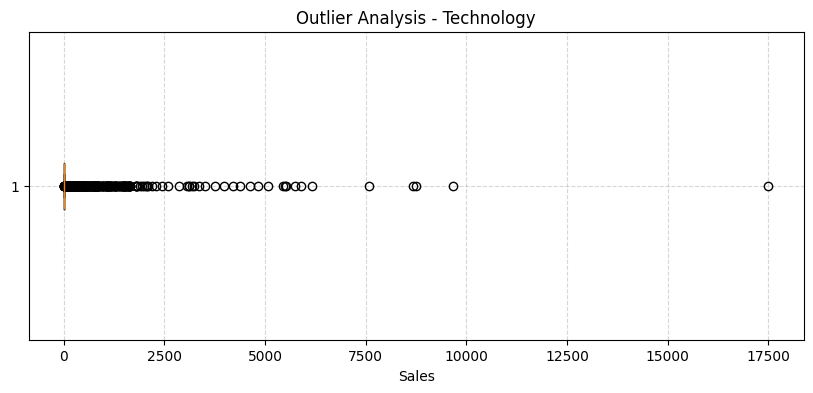

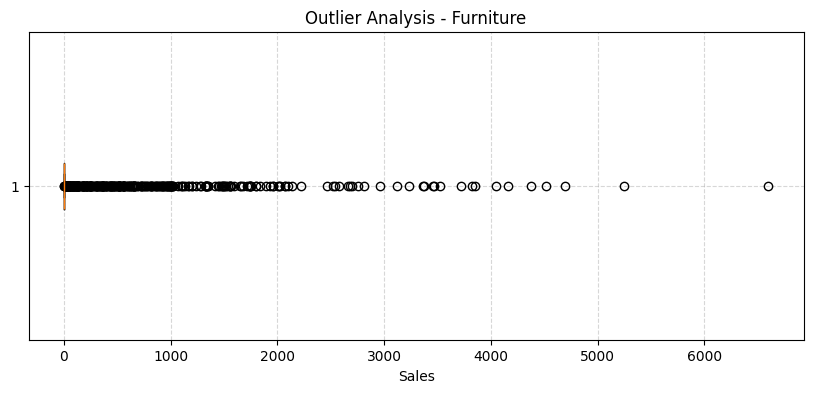

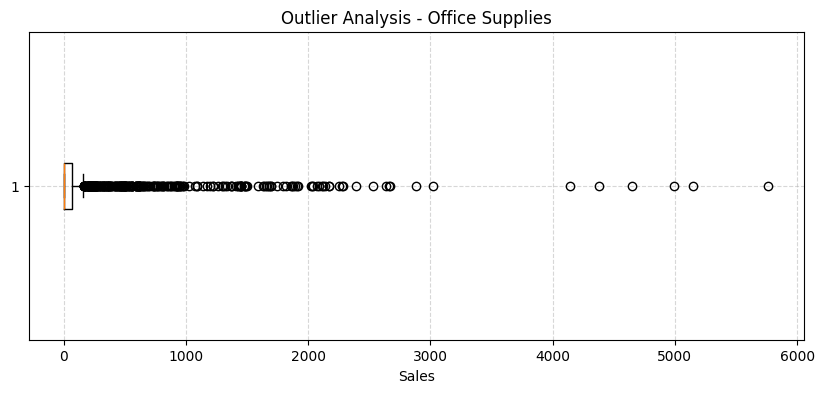

In [10]:
print("=== VISUALISASI OUTLIER PER KATEGORI ===")

for category in df_ts_category_full['Category'].unique():
    temp = df_ts_category_full[
        df_ts_category_full['Category'] == category
    ]

    plt.figure(figsize=(10, 4))
    plt.boxplot(temp['y'], vert=False)
    plt.title(f"Outlier Analysis - {category}")
    plt.xlabel("Sales")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

11. Outlier Treatment dengan IQR Capping

In [11]:
print("=== OUTLIER TREATMENT: IQR CAPPING ===")

df_ts_category_full['y_original'] = df_ts_category_full['y']
df_ts_category_full['y_capped'] = df_ts_category_full['y']
df_ts_category_full['is_outlier'] = 0

for category in df_ts_category_full['Category'].unique():
    temp = df_ts_category_full[
        df_ts_category_full['Category'] == category
    ]

    Q1 = temp['y'].quantile(0.25)
    Q3 = temp['y'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = max(0, Q1 - 1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR

    mask = df_ts_category_full['Category'] == category

    df_ts_category_full.loc[mask, 'is_outlier'] = (
        (df_ts_category_full.loc[mask, 'y'] < lower_bound) |
        (df_ts_category_full.loc[mask, 'y'] > upper_bound)
    ).astype(int)

    df_ts_category_full.loc[mask, 'y_capped'] = (
        df_ts_category_full.loc[mask, 'y']
        .clip(lower=lower_bound, upper=upper_bound)
    )

print("Outlier treatment selesai.")

df_ts_category_full[[
    'ds',
    'Category',
    'y_original',
    'y_capped',
    'is_outlier'
]].head()

=== OUTLIER TREATMENT: IQR CAPPING ===
Outlier treatment selesai.


,ds,Category,y_original,y_capped,is_outlier
0,2015-01-02,Technology,468.90,0.0,1
1,2015-01-03,Technology,5.94,0.0,1
2,2015-01-04,Technology,0.00,0.0,0
3,2015-01-05,Technology,0.00,0.0,0
4,2015-01-06,Technology,881.93,0.0,1


Catatan: y_original tetap disimpan sebagai data asli. y_capped digunakan untuk mengurangi pengaruh nilai ekstrem agar model tidak terlalu jauh mengikuti spike.

12. Lag Feature

In [12]:
print("=== LAG FEATURE ===")

df_ts_category_full = df_ts_category_full.sort_values(
    ['Category', 'ds']
).reset_index(drop=True)

for lag in [1, 7, 14]:
    df_ts_category_full[f'lag_{lag}'] = (
        df_ts_category_full
        .groupby('Category')['y_capped']
        .shift(lag)
    )

df_ts_category_full[[
    'ds',
    'Category',
    'y_capped',
    'lag_1',
    'lag_7',
    'lag_14'
]].head(20)

=== LAG FEATURE ===


,ds,Category,y_capped,lag_1,lag_7,lag_14
0,2015-01-02,Furniture,0.0,NaN,NaN,NaN
1,2015-01-03,Furniture,0.0,0.0,NaN,NaN
2,2015-01-04,Furniture,0.0,0.0,NaN,NaN
3,2015-01-05,Furniture,0.0,0.0,NaN,NaN
4,2015-01-06,Furniture,0.0,0.0,NaN,NaN
5,2015-01-07,Furniture,0.0,0.0,NaN,NaN
6,2015-01-08,Furniture,0.0,0.0,NaN,NaN
7,2015-01-09,Furniture,0.0,0.0,0.0,NaN
8,2015-01-10,Furniture,0.0,0.0,0.0,NaN
9,2015-01-11,Furniture,0.0,0.0,0.0,NaN


13. Rolling Statistics

In [13]:
print("=== ROLLING STATISTICS ===")

for window in [7, 30]:
    df_ts_category_full[f'rolling_mean_{window}'] = (
        df_ts_category_full
        .groupby('Category')['y_capped']
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

feature_cols = [
    'lag_1',
    'lag_7',
    'lag_14',
    'rolling_mean_7',
    'rolling_mean_30'
]

df_ts_category_full[feature_cols] = (
    df_ts_category_full[feature_cols]
    .fillna(0)
)

df_ts_category_full[[
    'ds',
    'Category',
    'y_capped',
    'rolling_mean_7',
    'rolling_mean_30'
]].head(20)

=== ROLLING STATISTICS ===


,ds,Category,y_capped,rolling_mean_7,rolling_mean_30
0,2015-01-02,Furniture,0.0,0.0,0.0
1,2015-01-03,Furniture,0.0,0.0,0.0
2,2015-01-04,Furniture,0.0,0.0,0.0
3,2015-01-05,Furniture,0.0,0.0,0.0
4,2015-01-06,Furniture,0.0,0.0,0.0
5,2015-01-07,Furniture,0.0,0.0,0.0
6,2015-01-08,Furniture,0.0,0.0,0.0
7,2015-01-09,Furniture,0.0,0.0,0.0
8,2015-01-10,Furniture,0.0,0.0,0.0
9,2015-01-11,Furniture,0.0,0.0,0.0


14. Agregasi Mingguan

In [14]:
print("=== AGREGASI MINGGUAN ===")

df_weekly = (
    df_ts_category_full
    .set_index('ds')
    .groupby('Category')
    .resample('W')
    .agg({
        'y_original': 'sum',
        'y_capped': 'sum',
        'is_holiday': 'max',
        'is_promo': 'max',
        'is_weekend': 'max'
    })
    .reset_index()
)

df_weekly = df_weekly.rename(
    columns={
        'y_capped': 'y'
    }
)

df_weekly['day_of_week'] = df_weekly['ds'].dt.dayofweek
df_weekly['month'] = df_weekly['ds'].dt.month
df_weekly['quarter'] = df_weekly['ds'].dt.quarter
df_weekly['year'] = df_weekly['ds'].dt.year

df_weekly.head()

=== AGREGASI MINGGUAN ===


,Category,ds,y_original,y,is_holiday,is_promo,is_weekend,day_of_week,month,quarter,year
0,Furniture,2015-01-04,1893.995,0.0,1.0,0.0,1,6,1,1,2015
1,Furniture,2015-01-11,2099.868,0.0,0.0,0.0,1,6,1,1,2015
2,Furniture,2015-01-18,4513.606,0.0,0.0,0.0,1,6,1,1,2015
3,Furniture,2015-01-25,0.000,0.0,0.0,0.0,1,6,1,1,2015
4,Furniture,2015-02-01,0.000,0.0,0.0,0.0,1,6,2,1,2015


15. Agregasi Bulanan

In [15]:
print("=== AGREGASI BULANAN ===")

df_monthly = (
    df_ts_category_full
    .set_index('ds')
    .groupby('Category')
    .resample('M')
    .agg({
        'y_original': 'sum',
        'y_capped': 'sum',
        'is_holiday': 'max',
        'is_promo': 'max'
    })
    .reset_index()
)

df_monthly = df_monthly.rename(
    columns={
        'y_capped': 'y'
    }
)

df_monthly['month'] = df_monthly['ds'].dt.month
df_monthly['quarter'] = df_monthly['ds'].dt.quarter
df_monthly['year'] = df_monthly['ds'].dt.year

df_monthly.head()

=== AGREGASI BULANAN ===


/tmp/ipykernel_2420/3722616144.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


,Category,ds,y_original,y,is_holiday,is_promo,month,quarter,year
0,Furniture,2015-01-31,8507.469,0.0,1.0,0.0,1,1,2015
1,Furniture,2015-02-28,1693.850,0.0,0.0,0.0,2,1,2015
2,Furniture,2015-03-31,3574.659,0.0,0.0,0.0,3,1,2015
3,Furniture,2015-04-30,1803.958,0.0,0.0,0.0,4,2,2015
4,Furniture,2015-05-31,2798.821,0.0,0.0,0.0,5,2,2015


16. Safety Stock dan Reorder Point Per Kategori

In [16]:
print("=== SAFETY STOCK & REORDER POINT PER KATEGORI ===")

lead_time_days = 7
service_level_z = 1.65

inventory_results = []

for category in df_ts_category_full['Category'].unique():
    temp = df_ts_category_full[
        df_ts_category_full['Category'] == category
    ]

    avg_daily_demand = temp['y_capped'].mean()
    std_daily_demand = temp['y_capped'].std()
    max_daily_demand = temp['y_capped'].max()

    safety_stock = (
        service_level_z
        * std_daily_demand
        * np.sqrt(lead_time_days)
    )

    reorder_point = (
        avg_daily_demand
        * lead_time_days
    ) + safety_stock

    inventory_results.append({
        'Category': category,
        'Average Daily Demand': round(avg_daily_demand, 2),
        'Max Daily Demand': round(max_daily_demand, 2),
        'Std Daily Demand': round(std_daily_demand, 2),
        'Lead Time (Days)': lead_time_days,
        'Service Level Z': service_level_z,
        'Safety Stock': round(safety_stock, 2),
        'Reorder Point (ROP)': round(reorder_point, 2)
    })

inventory_df = pd.DataFrame(inventory_results)

inventory_df

=== SAFETY STOCK & REORDER POINT PER KATEGORI ===


,Category,Average Daily Demand,Max Daily Demand,Std Daily Demand,Lead Time (Days),Service Level Z,Safety Stock,Reorder Point (ROP)
0,Furniture,0.0,0.00,0.0,7,1.65,0.00,0.0
1,Office Supplies,38.9,161.13,65.4,7,1.65,285.52,557.8
2,Technology,0.0,0.00,0.0,7,1.65,0.00,0.0


Catatan: Safety Stock dan ROP dihitung per kategori agar rekomendasi stok lebih realistis dan tidak dicampur secara global.

17. Visualisasi Tren Penjualan Per Kategori

=== VISUALISASI TREN PENJUALAN PER KATEGORI ===


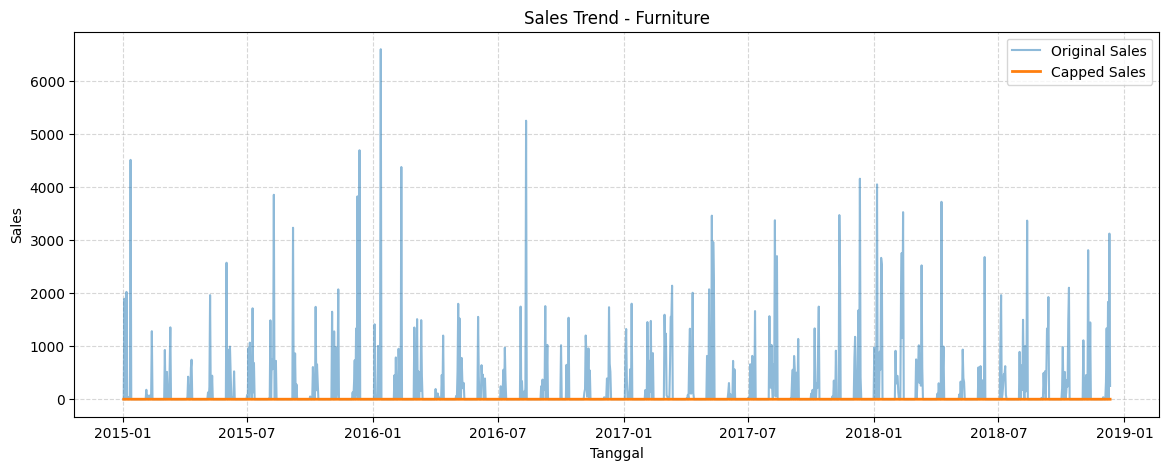

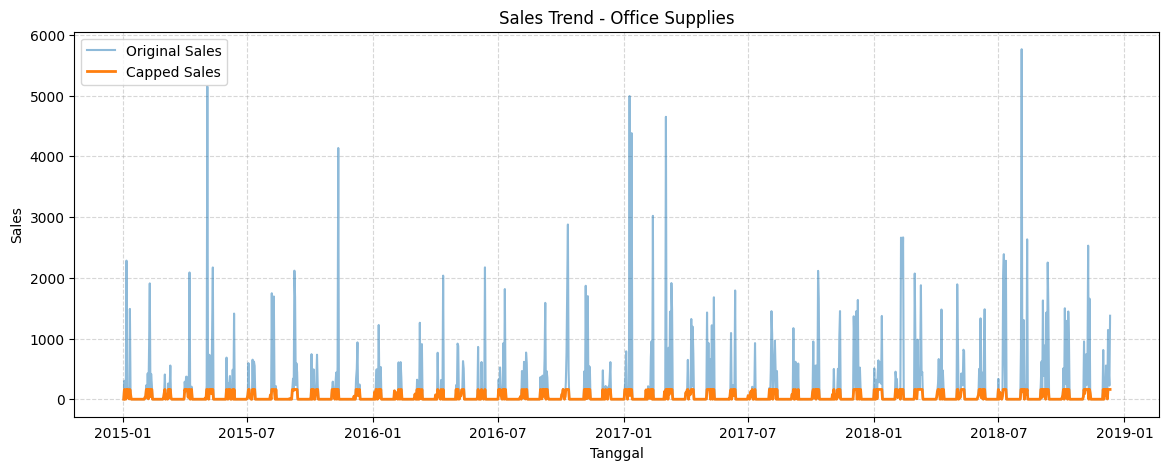

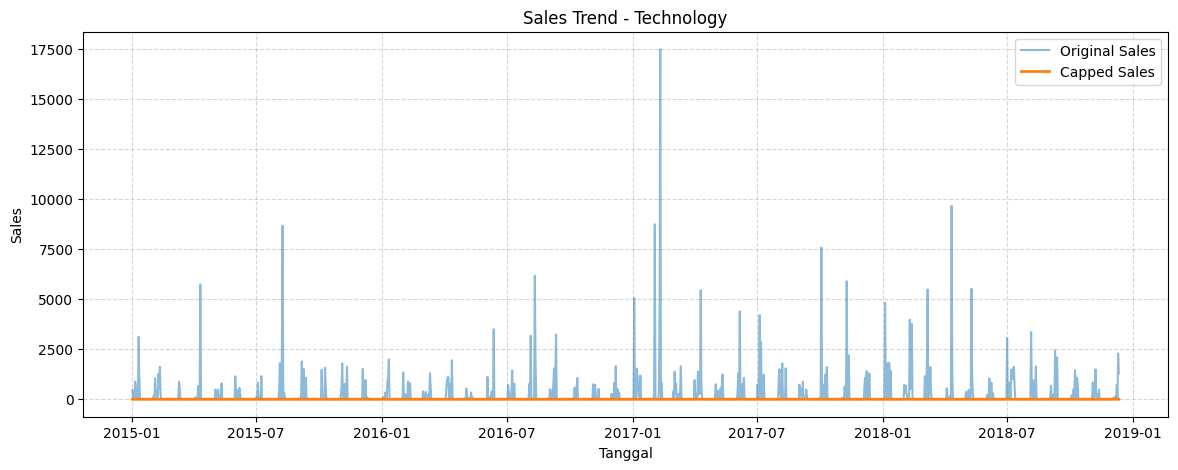

In [17]:
print("=== VISUALISASI TREN PENJUALAN PER KATEGORI ===")

for category in df_ts_category_full['Category'].unique():
    temp = df_ts_category_full[
        df_ts_category_full['Category'] == category
    ]

    plt.figure(figsize=(14, 5))
    plt.plot(
        temp['ds'],
        temp['y_original'],
        label='Original Sales',
        alpha=0.5
    )

    plt.plot(
        temp['ds'],
        temp['y_capped'],
        label='Capped Sales',
        linewidth=2
    )

    plt.title(f"Sales Trend - {category}")
    plt.xlabel("Tanggal")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

Catatan: Membandingkan sales asli dan sales setelah capping agar terlihat efek outlier treatment.

18. Export Dataset Final

In [18]:
print("=== EXPORT DATASET FINAL ===")

output_dir = "processed_data"
os.makedirs(output_dir, exist_ok=True)

df_ts_global.to_csv(
    f"{output_dir}/time_series_global.csv",
    index=False
)

df_ts_category_full.to_csv(
    f"{output_dir}/time_series_category_feature_engineered.csv",
    index=False
)

df_weekly.to_csv(
    f"{output_dir}/time_series_category_weekly.csv",
    index=False
)

df_monthly.to_csv(
    f"{output_dir}/time_series_category_monthly.csv",
    index=False
)

df_outlier_summary.to_csv(
    f"{output_dir}/outlier_summary.csv",
    index=False
)

inventory_df.to_csv(
    f"{output_dir}/inventory_summary.csv",
    index=False
)

print("Dataset berhasil diexport:")
print("- time_series_global.csv")
print("- time_series_category_feature_engineered.csv")
print("- time_series_category_weekly.csv")
print("- time_series_category_monthly.csv")
print("- outlier_summary.csv")
print("- inventory_summary.csv")

=== EXPORT DATASET FINAL ===
Dataset berhasil diexport:
- time_series_global.csv
- time_series_category_feature_engineered.csv
- time_series_category_weekly.csv
- time_series_category_monthly.csv
- outlier_summary.csv
- inventory_summary.csv
